# High-dimensional Gaussian mixture experiment

This notebook compares four Gaussian variational optimization schemes on a random high-dimensional Gaussian mixture target:
- **BW** (Gaussian Wasserstein gradient flow),
- **CBO** (consensus-based optimization in the Gaussian parameterization),
- **SVGD** (Stein variational Gaussian dynamics),
- **FR** (Fisher--Rao flow).

The first experiment shows a **single representative 10-dimensional instance**.  
The second experiment repeats the comparison across **multiple independently generated instances** and reports the **median relative KL trajectory**, normalized by the best KL attained on each instance. This gives a more stable view of method performance than a single random draw.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from gmm_target import random_gmm_nd
from sigma_points import expect_scalar, unscented_points
from variational_gp import VariationalGP, VGPConfig
from variational_Stein import VariationalStein
from variational_FR import VariationalFR
from cbo import LBWCBO, CBOConfig, GaussianParticle
from geometry import _sym


def expect_scalar_auto(fn, m, S, *, mc_threshold=10, mc_N=1000, alpha_small_dim=1.5):
    """Adaptive expectation: use UT in moderate dimension and MC otherwise."""
    return expect_scalar(
        fn,
        m,
        S,
        mc_threshold=mc_threshold,
        mc_N=mc_N,
        alpha_small_dim=alpha_small_dim,
    )


def kl_q_to_p(gmm, m, S):
    return gmm.KL_q_to_p(m, S, expect_scalar_auto)


def expect_grad_ut(gmm, m, S, alpha=1.0, beta=2.0, kappa=0.0):
    pts, Wm, _ = unscented_points(m, S, alpha=alpha, beta=beta, kappa=kappa)
    g = np.zeros_like(m)
    for w, x in zip(Wm, pts):
        g += w * gmm.gradV(x)
    return g


def expect_cross_ut(gmm, m, S, alpha=1.0, beta=2.0, kappa=0.0):
    pts, Wm, _ = unscented_points(m, S, alpha=alpha, beta=beta, kappa=kappa)
    C = np.zeros((m.size, m.size), dtype=float)
    for w, x in zip(Wm, pts):
        dx = x - m
        C += w * np.outer(gmm.gradV(x), dx)
    return C


def expect_hess_ut(gmm, m, S, alpha=1.0, beta=2.0, kappa=0.0):
    pts, Wm, _ = unscented_points(m, S, alpha=alpha, beta=beta, kappa=kappa)
    H = np.zeros((m.size, m.size), dtype=float)
    for w, x in zip(Wm, pts):
        H += w * gmm.hessV(x)
    return 0.5 * (H + H.T)


def make_particles(m0, S0, rng, d, N=100, mean_scale=0.5, cov_scale=0.1):
    particles = []
    for _ in range(N):
        m_i = m0 + mean_scale * rng.normal(size=d)

        A = rng.uniform(-0.5, 0.5, size=(d, d))
        A = _sym(A)
        V_i = S0 + cov_scale * (A @ A.T)

        particles.append(GaussianParticle(m_i, V_i))
    return particles


def make_random_problem(d, n_components, seed, *, mean_radius=3.0, lam_min=0.4, lam_max=2.0):
    rng = np.random.default_rng(seed)
    gmm = random_gmm_nd(
        d,
        n_components,
        rng=rng,
        mean_radius=mean_radius,
        lam_min=lam_min,
        lam_max=lam_max,
    )
    m0 = rng.uniform(-3.0, 3.0, size=d)
    S0 = np.eye(d)
    return gmm, m0, S0, rng


def run_methods(gmm, m0, S0, *, T, dt, nparts=100, seed=0):
    """Run all methods on one instance and return KL trajectories."""
    dt_map = {
        "BW": dt,
        "CBO": dt,
        "SVGD": dt / 20,
        "FR": dt / 20,
    }
    steps = {name: int(np.floor(T / dt_i)) for name, dt_i in dt_map.items()}
    results = {}

    # BW
    try:
        bw = VariationalGP(
            expect_grad=lambda m, S: expect_grad_ut(gmm, m, S, alpha=1.0),
            expect_cross=lambda m, S: expect_cross_ut(gmm, m, S, alpha=1.0),
            cfg=VGPConfig(dt=dt_map["BW"], steps=steps["BW"], seed=seed),
        )
        traj_bw = bw.run(m0, S0)
        results["BW"] = {
            "t": np.arange(len(traj_bw)) * dt_map["BW"],
            "kl": np.array([kl_q_to_p(gmm, m, S) for (m, S) in traj_bw], dtype=float),
        }
    except Exception as exc:
        results["BW"] = {"error": f"{type(exc).__name__}: {exc}"}

    # CBO
    try:
        rng_cbo = np.random.default_rng(seed)
        particles = make_particles(m0, S0, rng_cbo, d=m0.size, N=nparts)
        energy = lambda m, S: kl_q_to_p(gmm, m, S)

        cbo_cfg = CBOConfig(
            alpha=1e4,
            sigma=2.5,
            lmbda=1.0,
            dt=dt_map["CBO"],
            seed=seed,
            n_update_base=100000,
        )
        cbo = LBWCBO(energy, cbo_cfg)
        traj_cbo, _ = cbo.run(particles, steps=steps["CBO"])
        results["CBO"] = {
            "t": np.arange(len(traj_cbo)) * dt_map["CBO"],
            "kl": np.array([kl_q_to_p(gmm, m, S) for (m, S) in traj_cbo], dtype=float),
        }
    except Exception as exc:
        results["CBO"] = {"error": f"{type(exc).__name__}: {exc}"}

    # SVGD
    try:
        svgd = VariationalStein(
            expect_grad=lambda m, S: expect_grad_ut(gmm, m, S, alpha=1.0),
            expect_hess=lambda m, S: expect_hess_ut(gmm, m, S, alpha=1.0),
            cfg=VGPConfig(dt=dt_map["SVGD"], steps=steps["SVGD"], seed=seed),
        )
        traj_svgd = svgd.run(m0, S0)
        results["SVGD"] = {
            "t": np.arange(len(traj_svgd)) * dt_map["SVGD"],
            "kl": np.array([kl_q_to_p(gmm, m, S) for (m, S) in traj_svgd], dtype=float),
        }
    except Exception as exc:
        results["SVGD"] = {"error": f"{type(exc).__name__}: {exc}"}

    # Fisher--Rao
    try:
        fr = VariationalFR(
            expect_grad=lambda m, S: expect_grad_ut(gmm, m, S, alpha=1.0),
            expect_hess=lambda m, S: expect_hess_ut(gmm, m, S, alpha=1.0),
            cfg=VGPConfig(dt=dt_map["FR"], steps=steps["FR"], seed=seed),
        )
        traj_fr = fr.run(m0, S0)
        results["FR"] = {
            "t": np.arange(len(traj_fr)) * dt_map["FR"],
            "kl": np.array([kl_q_to_p(gmm, m, S) for (m, S) in traj_fr], dtype=float),
        }
    except Exception as exc:
        results["FR"] = {"error": f"{type(exc).__name__}: {exc}"}

    return results


def plot_kl_curves(results, *, title):
    """Plot all successful KL trajectories on a common axis."""
    colors = {
        "CBO": "tab:red",
        "BW": "tab:blue",
        "SVGD": "tab:orange",
        "FR": "tab:green",
    }
    order = ["CBO", "BW", "SVGD", "FR"]
    successful = {name: res for name, res in results.items() if "error" not in res}

    if not successful:
        raise RuntimeError("No successful trajectories to plot.")

    all_vals = np.concatenate([res["kl"] for res in successful.values()])
    shift = 0.0
    if all_vals.min() <= 1e-8:
        shift = abs(all_vals.min()) + 1e-8

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    for name in order:
        if name in successful:
            ax.plot(
                successful[name]["t"],
                successful[name]["kl"] + shift,
                lw=2.0,
                color=colors[name],
                label=name,
            )

    ax.set_xlabel("time")
    ax.set_ylabel("KL(q‖p)")
    if all(np.all(res["kl"] + shift > 0) for res in successful.values()):
        ax.set_yscale("log")

    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    plt.show()


## Single-instance comparison

We first generate one random Gaussian mixture in dimension $d=10$ with $K=5$ components and initialize all methods from the same Gaussian approximation.  
This experiment is meant as a representative trajectory plot: it shows how quickly each method decreases the forward KL divergence $\mathrm{KL}(q\|p)$ over time on one fixed target.


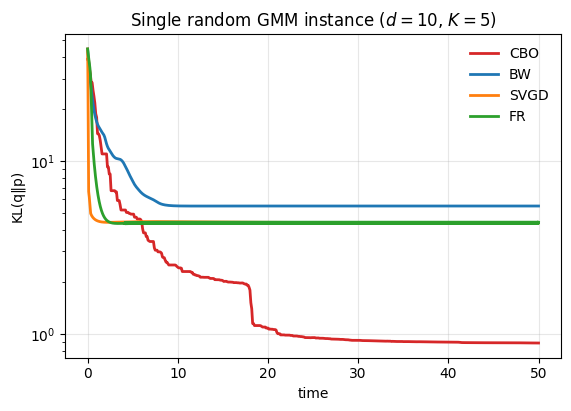

BW  : KL start=44.5737, final=5.50023
CBO : KL start=38.9088, final=0.88579
SVGD: KL start=44.5737, final=4.39813
FR  : KL start=44.5737, final=4.43062


In [2]:
# Settings for one instance
seed = 0
d = 10
K = 5
T = 50.0
dt = 0.1

gmm, m0, S0, _ = make_random_problem(d, K, seed)
results_single = run_methods(gmm, m0, S0, T=T, dt=dt, nparts=100, seed=seed)

plot_kl_curves(results_single, title=rf"Single random GMM instance ($d={d}$, $K={K}$)")

for name in ["BW", "CBO", "SVGD", "FR"]:
    res = results_single[name]
    if "error" in res:
        print(f"{name}: failed ({res['error']})")
    else:
        print(f"{name:4s}: KL start={res['kl'][0]:.6g}, final={res['kl'][-1]:.6g}")


## Multi-instance benchmark
 
To obtain a more robust comparison, we repeat the experiment over several independently generated Gaussian mixtures and initial conditions, then normalize each run by the **best KL value reached on that instance by any method**. The median of these relative KL curves summarizes typical performance while preserving the per-instance difficulty of the problem.


In [ ]:
# Settings for the aggregated comparison
rng_master = np.random.default_rng(0)
M = 10
d = 10
Kcomp = 5
T = 75.0
dt = 0.1
nparts = 100
max_attempts = 5 * M

successful_runs = []
attempts = 0

while len(successful_runs) < M and attempts < max_attempts:
    seed_i = int(rng_master.integers(1 << 32))
    gmm, m0, S0, _ = make_random_problem(d, Kcomp, seed_i)
    results_i = run_methods(gmm, m0, S0, T=T, dt=dt, nparts=nparts, seed=seed_i)

    failed = [name for name, res in results_i.items() if "error" in res]
    if failed:
        print(f"skipping seed {seed_i} because {', '.join(failed)} failed")
    else:
        successful_runs.append(results_i)
        print(f"accepted {len(successful_runs)}/{M}: seed {seed_i}")

    attempts += 1

if len(successful_runs) < M:
    raise RuntimeError(
        f"Only obtained {len(successful_runs)} fully successful runs out of the requested {M}."
    )

# Collect KL arrays and common time grids
t_bw = successful_runs[0]["BW"]["t"]
t_cbo = successful_runs[0]["CBO"]["t"]
t_svgd = successful_runs[0]["SVGD"]["t"]
t_fr = successful_runs[0]["FR"]["t"]

KLs_bw = np.vstack([run["BW"]["kl"] for run in successful_runs])
KLs_cbo = np.vstack([run["CBO"]["kl"] for run in successful_runs])
KLs_svgd = np.vstack([run["SVGD"]["kl"] for run in successful_runs])
KLs_fr = np.vstack([run["FR"]["kl"] for run in successful_runs])

# Instance-wise normalization:
# K* is the best KL reached on that instance across all methods and all times.
Kstar = np.minimum.reduce([
    KLs_bw.min(axis=1),
    KLs_cbo.min(axis=1),
    KLs_svgd.min(axis=1),
    KLs_fr.min(axis=1),
])
Kstar = np.maximum(Kstar, 1e-12)

Rel_bw = np.maximum(KLs_bw / Kstar[:, None], 1.0)
Rel_cbo = np.maximum(KLs_cbo / Kstar[:, None], 1.0)
Rel_svgd = np.maximum(KLs_svgd / Kstar[:, None], 1.0)
Rel_fr = np.maximum(KLs_fr / Kstar[:, None], 1.0)

bw_med = np.median(Rel_bw, axis=0)
cbo_med = np.median(Rel_cbo, axis=0)
svgd_med = np.median(Rel_svgd, axis=0)
fr_med = np.median(Rel_fr, axis=0)

# Plot median relative KL curves with final-time boxplots
fig, ax = plt.subplots(figsize=(6.6, 4.4), constrained_layout=True)

ax.plot(t_cbo, cbo_med, lw=2.2, color="tab:red", label="CBO")
ax.plot(t_bw, bw_med, lw=2.2, color="tab:blue", label="BW")
ax.plot(t_svgd, svgd_med, lw=2.2, color="tab:orange", label="SVGD")
ax.plot(t_fr, fr_med, lw=2.2, color="tab:green", label="FR")

ax.axhline(1.0, ls="--", c="k", lw=1.0)
ax.set_xlabel("time")
ax.set_ylabel("Relative KL divergence")
ax.set_yscale("log")
ax.set_ylim([0.9, 40])
ax.set_title(rf"Median relative KL across {M} random GMM instances ($d={d}$, $K={Kcomp}$)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", frameon=False)

axins = inset_axes(ax, width="38%", height="42%", loc="upper right", borderpad=1.2)
final_data = [
    Rel_cbo[:, -1],
    Rel_bw[:, -1],
    Rel_svgd[:, -1],
    Rel_fr[:, -1],
]

bp = axins.boxplot(
    final_data,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
)

colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor(color)
    patch.set_linewidth(1.2)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

for whisker in bp["whiskers"]:
    whisker.set_color("0.4")
    whisker.set_linewidth(1.0)

for cap in bp["caps"]:
    cap.set_color("0.4")
    cap.set_linewidth(1.0)

axins.set_xticks([])
axins.set_title("final rel. KL", fontsize=8, pad=2)
axins.set_yscale("log")
axins.tick_params(axis="y", which="both", labelsize=8)

plt.show()

print(f"successful runs = {len(successful_runs)} (attempted {attempts})")
print(f"CBO : median start={cbo_med[0]:.6g}, final={cbo_med[-1]:.6g}")
print(f"BW  : median start={bw_med[0]:.6g},  final={bw_med[-1]:.6g}")
print(f"SVGD: median start={svgd_med[0]:.6g}, final={svgd_med[-1]:.6g}")
print(f"FR  : median start={fr_med[0]:.6g},  final={fr_med[-1]:.6g}")
